# Thompson Sampling

## Learning Objectives

1. **Explain** Thompson Sampling as Bayesian posterior matching
2. **Derive** the Beta-Bernoulli conjugate update
3. **Prove** the connection between TS and probability of optimality
4. **Describe** the $O(\ln T)$ regret guarantee and empirical advantages over UCB1
5. **Implement** Thompson Sampling and compare to UCB1 on a Bernoulli bandit


## Problem Statement

### Bayesian Approach to Exploration

UCB1 uses **confidence intervals** derived from worst-case concentration inequalities (Hoeffding). Thompson Sampling (Thompson 1933) takes a Bayesian view:

- Maintain a **posterior distribution** $P(\theta_i \mid \text{data})$ over the true reward parameter of each arm
- At each round: **sample** $\tilde{\theta}_i \sim P(\theta_i \mid \text{data})$ for each arm; pull $i^* = \arg\max_i \tilde{\theta}_i$
- After observing reward: **update** posterior via Bayes' rule

**Key principle:** Pull arm $i$ with probability equal to the **probability that $i$ is the best arm** — this is exactly what posterior sampling achieves.

### Beta-Bernoulli Conjugate Model

For Bernoulli rewards (0/1 success/failure):
- **Prior:** $\theta_i \sim \text{Beta}(\alpha_i, \beta_i)$
- **Likelihood:** $r \mid \theta_i \sim \text{Bernoulli}(\theta_i)$
- **Posterior update:** After observing $r$:
  - $r = 1$: $\alpha_i \leftarrow \alpha_i + 1$
  - $r = 0$: $\beta_i \leftarrow \beta_i + 1$
- **Posterior mean:** $\mathbb{E}[\theta_i \mid \text{data}] = \frac{\alpha_i}{\alpha_i + \beta_i}$


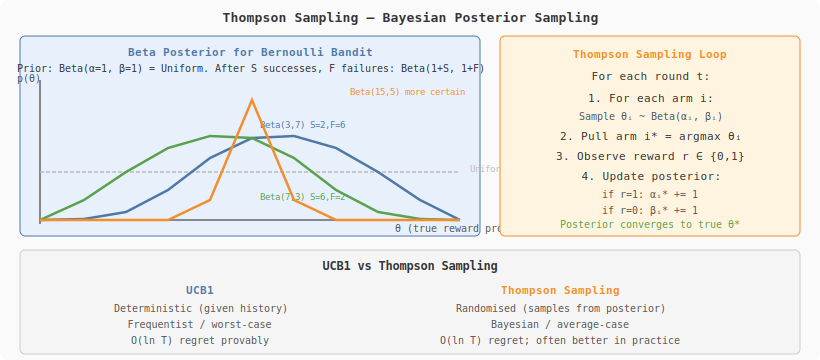

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="360" font-family="monospace" font-size="12">
  <rect width="820" height="360" fill="#fafafa" rx="8"/>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Thompson Sampling — Bayesian Posterior Sampling</text>

  <!-- Beta prior evolution -->
  <rect x="20" y="36" width="460" height="200" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="250" y="56" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">Beta Posterior for Bernoulli Bandit</text>
  <text x="250" y="72" text-anchor="middle" fill="#333" font-size="10">Prior: Beta(α=1, β=1) = Uniform. After S successes, F failures: Beta(1+S, 1+F)</text>

  <!-- axes -->
  <line x1="40"  y1="220" x2="460" y2="220" stroke="#666" stroke-width="1.5"/>
  <line x1="40"  y1="80"  x2="40"  y2="224" stroke="#666" stroke-width="1.5"/>
  <text x="454" y="232" text-anchor="middle" fill="#555" font-size="10">θ (true reward prob)</text>
  <text x="28"  y="82"   text-anchor="middle" fill="#555" font-size="10">p(θ)</text>
  <!-- uniform prior -->
  <line x1="40" y1="172" x2="460" y2="172" stroke="#bbb" stroke-width="1.5" stroke-dasharray="4,2"/>
  <text x="470" y="172" fill="#bbb" font-size="9">Uniform</text>
  <!-- Beta(3,7) skewed left -->
  <polyline points="40,220 84,219 126,212 168,190 210,158 252,138 294,136 336,148 378,172 420,200 460,220" fill="none" stroke="#4e79a7" stroke-width="2.5"/>
  <text x="260" y="128" fill="#4e79a7" font-size="9">Beta(3,7) S=2,F=6</text>
  <!-- Beta(7,3) skewed right -->
  <polyline points="40,220 84,200 126,172 168,148 210,136 252,138 294,158 336,190 378,212 420,219 460,220" fill="none" stroke="#59a14f" stroke-width="2.5"/>
  <text x="260" y="200" fill="#59a14f" font-size="9">Beta(7,3) S=6,F=2</text>
  <!-- narrow peaked -->
  <polyline points="40,220 168,220 210,200 252,100 294,200 336,220 460,220" fill="none" stroke="#f28e2b" stroke-width="2.5"/>
  <text x="350" y="95" fill="#f28e2b" font-size="9">Beta(15,5) more certain</text>

  <!-- TS steps -->
  <rect x="500" y="36" width="300" height="200" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="650" y="58" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Thompson Sampling Loop</text>
  <text x="650" y="80" text-anchor="middle" fill="#333" font-size="11">For each round t:</text>
  <text x="650" y="102" text-anchor="middle" fill="#333" font-size="11">1. For each arm i:</text>
  <text x="650" y="120" text-anchor="middle" fill="#555" font-size="10">   Sample θᵢ ~ Beta(αᵢ, βᵢ)</text>
  <text x="650" y="140" text-anchor="middle" fill="#333" font-size="11">2. Pull arm i* = argmax θᵢ</text>
  <text x="650" y="160" text-anchor="middle" fill="#333" font-size="11">3. Observe reward r ∈ {0,1}</text>
  <text x="650" y="180" text-anchor="middle" fill="#333" font-size="11">4. Update posterior:</text>
  <text x="650" y="198" text-anchor="middle" fill="#555" font-size="10">   if r=1: αᵢ* += 1</text>
  <text x="650" y="214" text-anchor="middle" fill="#555" font-size="10">   if r=0: βᵢ* += 1</text>
  <text x="650" y="228" text-anchor="middle" fill="#59a14f" font-size="10">Posterior converges to true θ*</text>

  <!-- Comparison -->
  <rect x="20" y="250" width="780" height="104" rx="5" fill="#f5f5f5" stroke="#ccc"/>
  <text x="410" y="270" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">UCB1 vs Thompson Sampling</text>
  <text x="200" y="294" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">UCB1</text>
  <text x="200" y="312" text-anchor="middle" fill="#555" font-size="10">Deterministic (given history)</text>
  <text x="200" y="328" text-anchor="middle" fill="#555" font-size="10">Frequentist / worst-case</text>
  <text x="200" y="344" text-anchor="middle" fill="#555" font-size="10">O(ln T) regret provably</text>
  <text x="560" y="294" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Thompson Sampling</text>
  <text x="560" y="312" text-anchor="middle" fill="#555" font-size="10">Randomised (samples from posterior)</text>
  <text x="560" y="328" text-anchor="middle" fill="#555" font-size="10">Bayesian / average-case</text>
  <text x="560" y="344" text-anchor="middle" fill="#555" font-size="10">O(ln T) regret; often better in practice</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Why Beta Distributions?

The Beta distribution is the **conjugate prior** for the Bernoulli likelihood:
$$P(\theta_i \mid S_i \text{ successes}, F_i \text{ failures}) \propto \theta_i^{S_i} (1-\theta_i)^{F_i} \cdot \underbrace{\theta_i^{\alpha_0-1}(1-\theta_i)^{\beta_0-1}}_{\text{prior}} = \text{Beta}(\alpha_0+S_i, \beta_0+F_i)$$

With uninformative prior $\text{Beta}(1, 1) = \text{Uniform}[0,1]$:
$$\theta_i \mid \text{data} \sim \text{Beta}(1 + S_i, 1 + F_i)$$

### Probability of Being Best

Thompson Sampling's key property: the probability that arm $i$ is selected equals $\Pr[\theta_i > \theta_j \forall j \neq i \mid \text{data}]$ — the **posterior probability of optimality**.

As data accumulates, the posterior for the best arm concentrates near $\mu^*$ → pulls of suboptimal arms decrease → regret vanishes.

### Regret Bound

**Theorem (Agrawal & Goyal 2012, Kaufmann et al. 2012):** Thompson Sampling achieves:
$$R(T) \leq \sum_{i: \mu_i < \mu^*} \frac{(1+\varepsilon) \ln T}{\text{KL}(\mu_i, \mu^*)} (1 + o(1))$$

This matches the **Lai-Robbins lower bound** — Thompson Sampling is **asymptotically optimal**.

**vs UCB1:** TS has the same $O(\ln T)$ asymptotic rate, but smaller constants empirically. TS also naturally handles non-stationarity (can add forgetting) and extends cleanly to complex reward models (Gaussian, contextual).

### Generalisation

- **Gaussian bandit:** Prior $\mathcal{N}(\mu_0, \sigma_0^2)$; posterior $\mathcal{N}(\hat{\mu}_n, \hat{\sigma}_n^2)$
- **Contextual bandit (LinUCB/LinTS):** Linear reward model; posterior over weight vector
- **Neural bandit:** Deep neural posterior with last-layer uncertainty


## Algorithm Steps

1. **Initialise:** $\alpha_i = 1, \beta_i = 1$ for all arms (uniform prior)
2. **For** each round $t = 1, \ldots, T$:
   - **Sample:** $\tilde{\theta}_i \sim \text{Beta}(\alpha_i, \beta_i)$ for each arm $i$
   - **Pull:** arm $i^* = \arg\max_i \tilde{\theta}_i$
   - **Observe** reward $r \in \{0, 1\}$
   - **Update:** $\alpha_{i^*} \mathrel{+}= r$;  $\beta_{i^*} \mathrel{+}= 1 - r$
3. **Output** arm counts, posterior means


In [2]:
import numpy as np
from scipy import stats


class ThompsonSampling:
    """
    Thompson Sampling for Bernoulli bandit.

    Prior: Beta(α=1, β=1) = Uniform[0,1]
    After S successes, F failures: posterior is Beta(1+S, 1+F)
    """
    def __init__(self, n_arms, alpha_prior=1.0, beta_prior=1.0):
        self.n_arms = n_arms
        self.alpha = np.full(n_arms, alpha_prior)  # successes + 1
        self.beta  = np.full(n_arms, beta_prior)   # failures  + 1

    def select(self, rng=None):
        """Sample θᵢ ~ Beta(αᵢ, βᵢ); pull arm with max sample."""
        if rng is None:
            samples = np.random.beta(self.alpha, self.beta)
        else:
            samples = rng.beta(self.alpha, self.beta)
        return int(np.argmax(samples))

    def update(self, arm, reward):
        """Bayesian update: conjugate Beta posterior."""
        if reward == 1:
            self.alpha[arm] += 1
        else:
            self.beta[arm]  += 1

    def posterior_means(self):
        """E[θᵢ] = αᵢ/(αᵢ+βᵢ) — posterior mean per arm."""
        return self.alpha / (self.alpha + self.beta)

    def confidence_intervals(self, ci=0.95):
        """Return 95% credible intervals per arm."""
        lo = np.array([stats.beta.ppf(0.025, a, b) for a, b in zip(self.alpha, self.beta)])
        hi = np.array([stats.beta.ppf(0.975, a, b) for a, b in zip(self.alpha, self.beta)])
        return lo, hi


def simulate_ts(agent, true_means, T, seed=0):
    rng_sim = np.random.default_rng(seed)
    rewards = []
    for t in range(T):
        arm = agent.select(rng=rng_sim)
        reward = int(rng_sim.random() < true_means[arm])
        agent.update(arm, reward)
        rewards.append(reward)
    return np.array(rewards)


# ── Comparison: UCB1 vs Thompson Sampling vs ε-greedy ──────────────────────
rng = np.random.default_rng(0)
true_means = np.array([0.2, 0.8, 0.5, 0.3])
n_arms = len(true_means)
mu_star = true_means.max()
T = 2000

# Reuse UCB1 from previous cell (define inline here)
class UCB1Local:
    def __init__(self, n):
        self.n = n; self.c = np.zeros(n, dtype=int); self.v = np.zeros(n); self.t = 0
    def select(self, rng=None):
        self.t += 1
        for i in range(self.n):
            if self.c[i] == 0: return i
        return int(np.argmax(self.v + np.sqrt(2*np.log(self.t)/self.c)))
    def update(self, arm, r):
        self.c[arm] += 1; self.v[arm] += (r - self.v[arm])/self.c[arm]

ucb_agent = UCB1Local(n_arms)
ts_agent  = ThompsonSampling(n_arms)

def sim_ucb(agent, T, seed):
    rng_s = np.random.default_rng(seed)
    rewards = []
    for _ in range(T):
        arm = agent.select()
        r = int(rng_s.random() < true_means[arm])
        agent.update(arm, r)
        rewards.append(r)
    return np.array(rewards)

r_ucb = sim_ucb(ucb_agent, T, seed=42)
r_ts  = simulate_ts(ts_agent, true_means, T, seed=42)

reg_ucb = np.cumsum(mu_star - r_ucb)
reg_ts  = np.cumsum(mu_star - r_ts)

print(f"Bernoulli bandit: true_means={true_means}, μ*={mu_star}")
print(f"\nAfter {T} rounds:")
print(f"  UCB1 cumulative regret:   {reg_ucb[-1]:.2f}")
print(f"  Thompson Sampling regret: {reg_ts[-1]:.2f}")
print(f"\nThompson Sampling posterior means: {ts_agent.posterior_means().round(3)}")
lo, hi = ts_agent.confidence_intervals()
print(f"95% credible intervals:")
for i, (l, h, m) in enumerate(zip(lo, hi, true_means)):
    print(f"  Arm {i}: [{l:.3f}, {h:.3f}]  true={m}")


Bernoulli bandit: true_means=[0.2 0.8 0.5 0.3], μ*=0.8

After 2000 rounds:
  UCB1 cumulative regret:   84.00
  Thompson Sampling regret: 10.00

Thompson Sampling posterior means: [0.167 0.801 0.545 0.25 ]
95% credible intervals:
  Arm 0: [0.005, 0.522]  true=0.2
  Arm 1: [0.783, 0.818]  true=0.8
  Arm 2: [0.340, 0.743]  true=0.5
  Arm 3: [0.037, 0.579]  true=0.3
